# Task 4: Insights and Recommendations

## Objective
Synthesize sentiment and thematic analysis into business-actionable
insights with clear visualizations and concrete product recommendations
for each Ethiopian bank.

## Business Scenarios Addressed
1. **Retaining Users** — Is slow loading a systemic issue across all apps?
2. **Enhancing Features** — What features do users want most?
3. **Managing Complaints** — What are the recurring complaint patterns?

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.chdir(r"C:\Users\pc\fintech-review-analytics")
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100

print("All imports successful")

All imports successful


In [11]:
df = pd.read_csv("data/raw/bank_reviews_analyzed.csv")
print(f"Loaded {len(df)} reviews")
print(df["bank"].value_counts())

Loaded 1452 reviews
bank
Bank of Abyssinia              499
Dashen Bank                    498
Commercial Bank of Ethiopia    455
Name: count, dtype: int64


## Plot 1: Overall Sentiment Comparison (Stacked Bar Chart)

This chart answers Scenario 1: How does sentiment compare across all three banks?

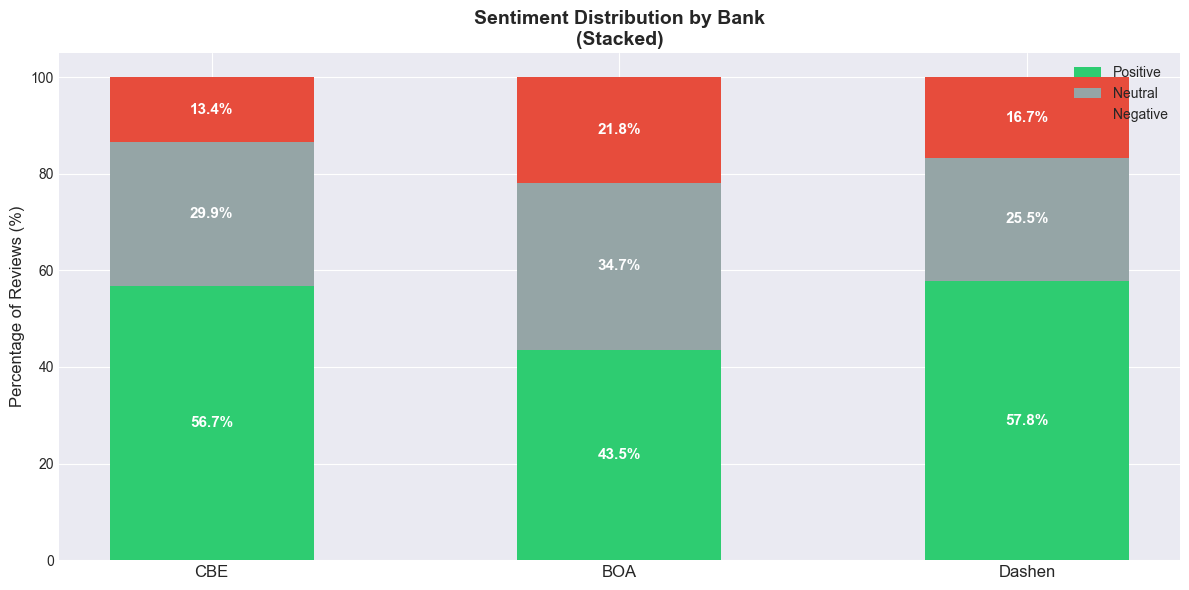

Plot 1 saved


In [12]:
banks = ["Commercial Bank of Ethiopia", "Bank of Abyssinia", "Dashen Bank"]
sentiment_data = {}

for bank in banks:
    bank_df = df[df["bank"] == bank]
    total = len(bank_df)
    sentiment_data[bank] = {
        "Positive": (bank_df["sentiment_label"] == "positive").sum() / total * 100,
        "Neutral": (bank_df["sentiment_label"] == "neutral").sum() / total * 100,
        "Negative": (bank_df["sentiment_label"] == "negative").sum() / total * 100
    }

sentiment_df = pd.DataFrame(sentiment_data).T

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(banks))
width = 0.5

bars1 = ax.bar(x, sentiment_df["Positive"], width, label="Positive", color="#2ecc71")
bars2 = ax.bar(x, sentiment_df["Neutral"], width, 
               bottom=sentiment_df["Positive"], label="Neutral", color="#95a5a6")
bars3 = ax.bar(x, sentiment_df["Negative"], width,
               bottom=sentiment_df["Positive"] + sentiment_df["Neutral"], 
               label="Negative", color="#e74c3c")

# Add percentage labels
for i, bank in enumerate(banks):
    pos = sentiment_df.loc[bank, "Positive"]
    neu = sentiment_df.loc[bank, "Neutral"]
    neg = sentiment_df.loc[bank, "Negative"]
    ax.text(i, pos/2, f'{pos:.1f}%', ha='center', va='center', 
            fontweight='bold', color='white', fontsize=11)
    ax.text(i, pos + neu/2, f'{neu:.1f}%', ha='center', va='center',
            fontweight='bold', color='white', fontsize=11)
    ax.text(i, pos + neu + neg/2, f'{neg:.1f}%', ha='center', va='center',
            fontweight='bold', color='white', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(["CBE", "BOA", "Dashen"], fontsize=12)
ax.set_ylabel("Percentage of Reviews (%)", fontsize=12)
ax.set_title("Sentiment Distribution by Bank\n(Stacked)", fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig("notebooks/plot1_sentiment_stacked.png", dpi=100, bbox_inches='tight')
plt.show()
print("Plot 1 saved")

## Plot 2: Rating Distribution per Bank

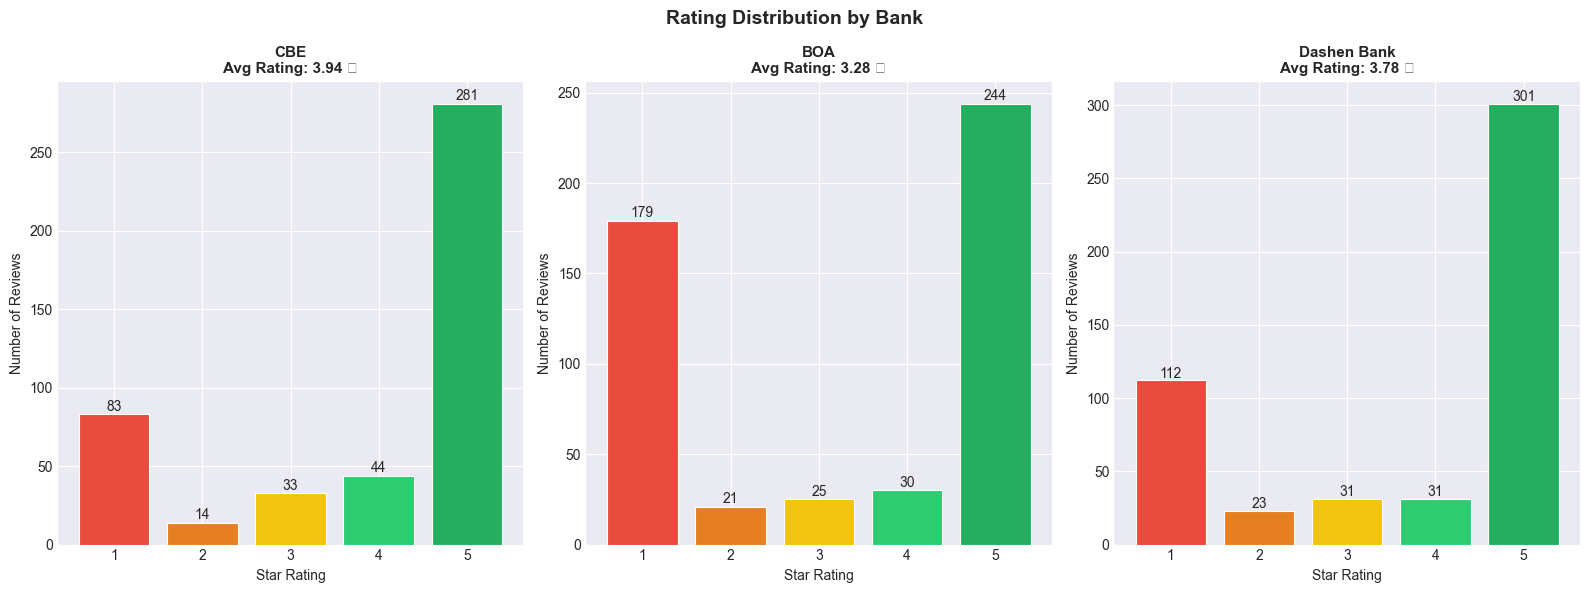

Plot 2 saved


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

for i, bank in enumerate(banks):
    bank_df = df[df["bank"] == bank]
    rating_counts = bank_df["rating"].value_counts().sort_index()
    
    axes[i].bar(rating_counts.index, rating_counts.values,
                color=colors, edgecolor='white', linewidth=0.8)
    
    avg = bank_df["rating"].mean()
    axes[i].set_title(f"{bank.replace('Commercial Bank of Ethiopia', 'CBE').replace('Bank of Abyssinia', 'BOA')}\nAvg Rating: {avg:.2f} ⭐", 
                      fontweight='bold', fontsize=11)
    axes[i].set_xlabel("Star Rating")
    axes[i].set_ylabel("Number of Reviews")
    axes[i].set_xticks([1, 2, 3, 4, 5])
    
    for j, (rating, count) in enumerate(rating_counts.items()):
        axes[i].text(rating, count + 2, str(count), ha='center', fontsize=10)

plt.suptitle("Rating Distribution by Bank", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/plot2_rating_distribution.png", dpi=100, bbox_inches='tight')
plt.show()
print("Plot 2 saved")

## Plot 3: Theme Frequency per Bank

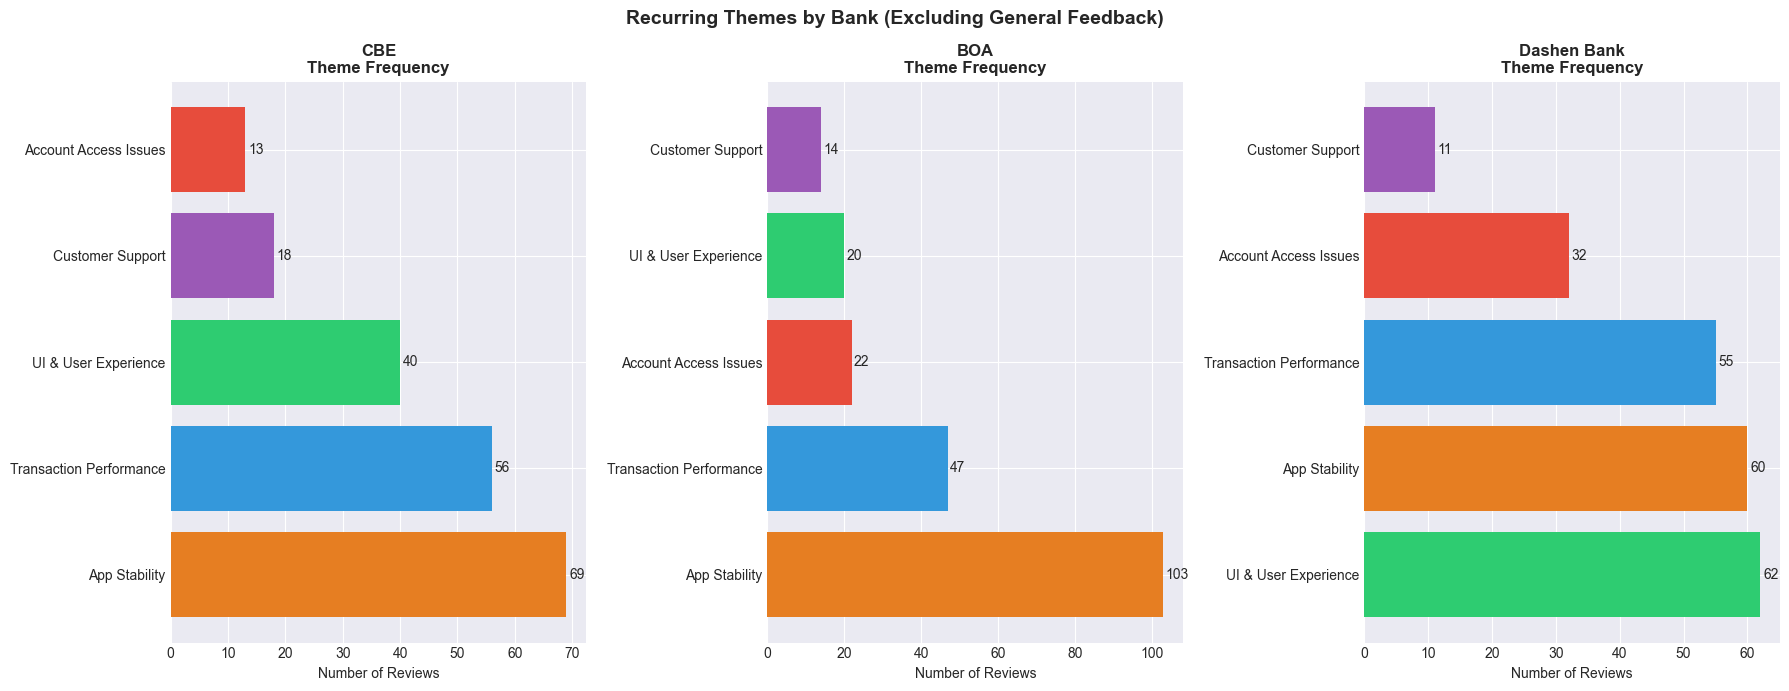

Plot 3 saved


In [14]:
theme_colors = {
    "App Stability": "#e67e22",
    "Transaction Performance": "#3498db",
    "UI & User Experience": "#2ecc71",
    "Account Access Issues": "#e74c3c",
    "Customer Support": "#9b59b6",
    "General Feedback": "#95a5a6"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, bank in enumerate(banks):
    bank_df = df[df["bank"] == bank]
    theme_counts = bank_df["identified_theme"].value_counts()
    theme_counts = theme_counts[theme_counts.index != "General Feedback"]
    
    colors = [theme_colors.get(t, "gray") for t in theme_counts.index]
    bars = axes[i].barh(theme_counts.index, theme_counts.values, color=colors)
    
    short_name = bank.replace("Commercial Bank of Ethiopia", "CBE").replace("Bank of Abyssinia", "BOA")
    axes[i].set_title(f"{short_name}\nTheme Frequency", fontweight='bold')
    axes[i].set_xlabel("Number of Reviews")
    
    for j, val in enumerate(theme_counts.values):
        axes[i].text(val + 0.5, j, str(val), va='center', fontsize=10)

plt.suptitle("Recurring Themes by Bank (Excluding General Feedback)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/plot3_themes.png", dpi=100, bbox_inches='tight')
plt.show()
print("Plot 3 saved")

## Plot 4: Sentiment Trend Over Time

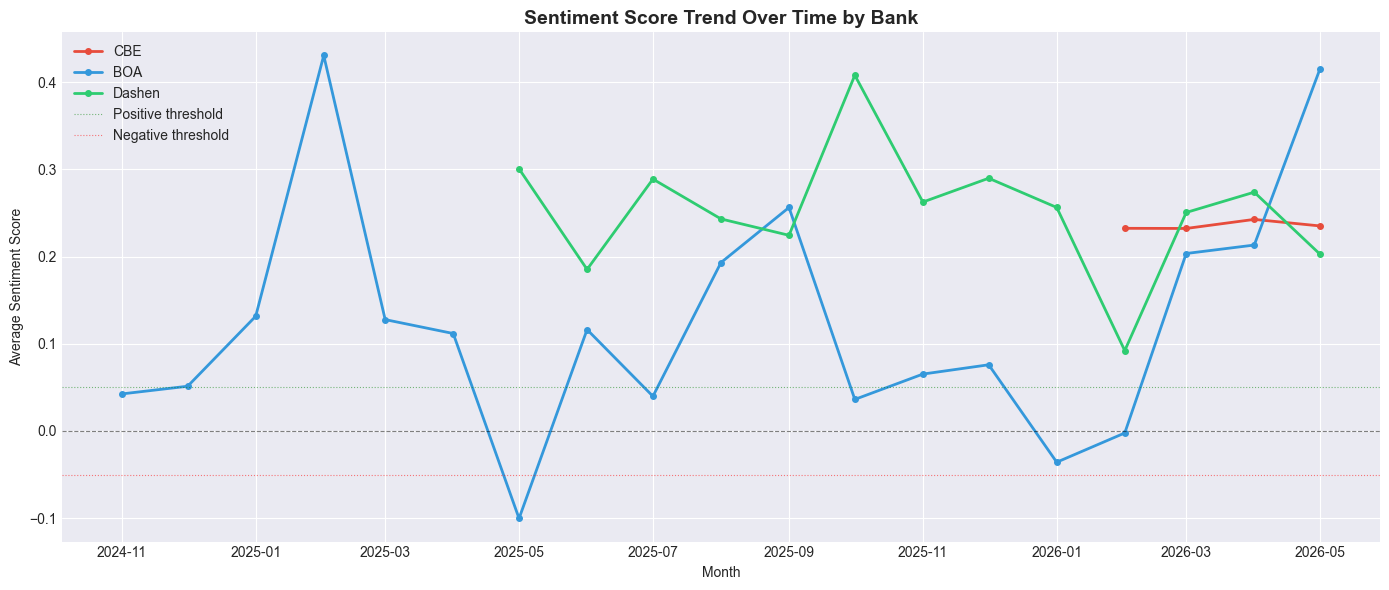

Plot 4 saved


In [15]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.to_period("M")

monthly = df.groupby(["month", "bank"])["sentiment_score"].mean().reset_index()
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

plt.figure(figsize=(14, 6))
bank_colors = {
    "Commercial Bank of Ethiopia": "#e74c3c",
    "Bank of Abyssinia": "#3498db",
    "Dashen Bank": "#2ecc71"
}
bank_labels = {
    "Commercial Bank of Ethiopia": "CBE",
    "Bank of Abyssinia": "BOA",
    "Dashen Bank": "Dashen"
}

for bank in banks:
    bank_data = monthly[monthly["bank"] == bank].sort_values("month_dt")
    plt.plot(bank_data["month_dt"], bank_data["sentiment_score"],
             marker='o', linewidth=2, markersize=4,
             color=bank_colors[bank], label=bank_labels[bank])

plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axhline(y=0.05, color='green', linestyle=':', linewidth=0.8, 
            alpha=0.5, label='Positive threshold')
plt.axhline(y=-0.05, color='red', linestyle=':', linewidth=0.8,
            alpha=0.5, label='Negative threshold')

plt.title("Sentiment Score Trend Over Time by Bank", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Average Sentiment Score")
plt.legend()
plt.tight_layout()
plt.savefig("notebooks/plot4_sentiment_trend.png", dpi=100, bbox_inches='tight')
plt.show()
print("Plot 4 saved")

## Plot 5: Satisfaction Drivers vs Pain Points

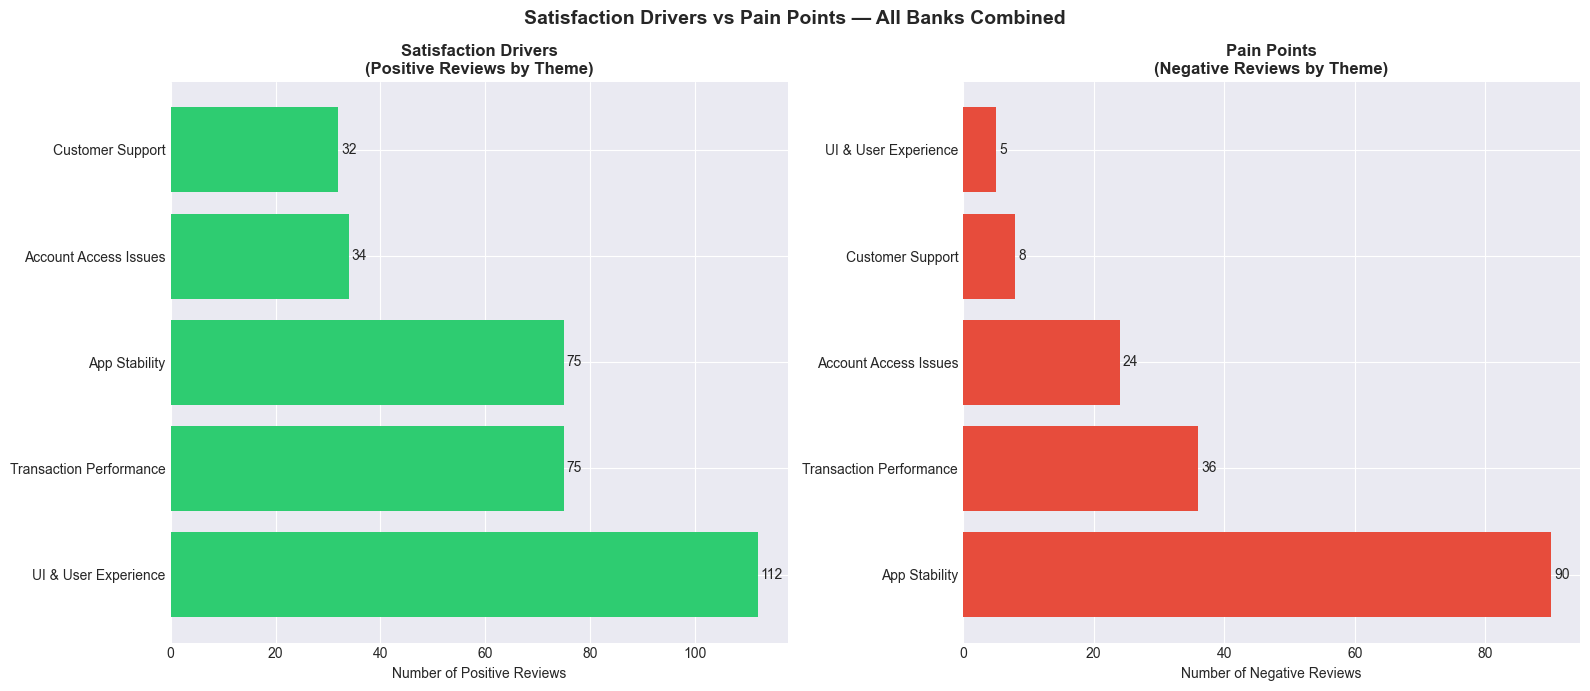

Plot 5 saved


In [16]:
# Positive reviews by theme = satisfaction drivers
# Negative reviews by theme = pain points

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Drivers: positive reviews per theme
drivers = df[df["sentiment_label"] == "positive"].groupby(
    "identified_theme").size().sort_values(ascending=False)
drivers = drivers[drivers.index != "General Feedback"]

axes[0].barh(drivers.index, drivers.values, color="#2ecc71")
axes[0].set_title("Satisfaction Drivers\n(Positive Reviews by Theme)", 
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel("Number of Positive Reviews")
for j, val in enumerate(drivers.values):
    axes[0].text(val + 0.5, j, str(val), va='center', fontsize=10)

# Pain points: negative reviews per theme
pain = df[df["sentiment_label"] == "negative"].groupby(
    "identified_theme").size().sort_values(ascending=False)
pain = pain[pain.index != "General Feedback"]

axes[1].barh(pain.index, pain.values, color="#e74c3c")
axes[1].set_title("Pain Points\n(Negative Reviews by Theme)",
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel("Number of Negative Reviews")
for j, val in enumerate(pain.values):
    axes[1].text(val + 0.5, j, str(val), va='center', fontsize=10)

plt.suptitle("Satisfaction Drivers vs Pain Points — All Banks Combined",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/plot5_drivers_painpoints.png", dpi=100, bbox_inches='tight')
plt.show()
print("Plot 5 saved")

## Key Insights and Recommendations

### Satisfaction Drivers (What users love)
### Pain Points (What frustrates users)
### Bank-Specific Recommendations

In [17]:
print("=" * 70)
print("KEY INSIGHTS AND RECOMMENDATIONS FOR OMEGA CONSULTANCY")
print("=" * 70)

for bank in banks:
    bank_df = df[df["bank"] == bank]
    short = bank.replace("Commercial Bank of Ethiopia","CBE").replace("Bank of Abyssinia","BOA")
    
    pos_df = bank_df[bank_df["sentiment_label"] == "positive"]
    neg_df = bank_df[bank_df["sentiment_label"] == "negative"]
    
    print(f"\n{'─'*60}")
    print(f"  {short}")
    print(f"{'─'*60}")
    print(f"  Total Reviews: {len(bank_df)} | Avg Rating: {bank_df['rating'].mean():.2f}")
    print(f"  Positive: {len(pos_df)} ({len(pos_df)/len(bank_df)*100:.1f}%) | "
          f"Negative: {len(neg_df)} ({len(neg_df)/len(bank_df)*100:.1f}%)")
    
    print(f"\n  ✅ SATISFACTION DRIVERS:")
    top_driver = pos_df["identified_theme"].value_counts().head(2)
    for theme, count in top_driver.items():
        if theme != "General Feedback":
            print(f"     → {theme}: {count} positive reviews")
    
    print(f"\n  ❌ PAIN POINTS:")
    top_pain = neg_df["identified_theme"].value_counts().head(2)
    for theme, count in top_pain.items():
        if theme != "General Feedback":
            print(f"     → {theme}: {count} negative reviews")

print(f"\n{'=' * 70}")
print("RECOMMENDATIONS")
print(f"{'=' * 70}")

print("""
CBE (Commercial Bank of Ethiopia):
  1. Address App Stability issues — 69 reviews mention crashes/errors.
     Priority: Fix login flow and reduce crash rate by 50% in next release.
  2. Improve Transaction Performance — 56 reviews cite slow transfers.
     Priority: Optimize backend processing for peak-hour transactions.
  3. Leverage strength: CBE has the highest positive rate (56.7%) —
     promote this in marketing and maintain UX quality.

BOA (Bank of Abyssinia):
  1. URGENT: App Stability — 103 negative reviews about crashes.
     BOA has the worst sentiment (43.5% positive). Stability must be
     the #1 engineering priority before any new features.
  2. Transaction Performance — 47 reviews cite delays.
     Implement real-time transaction status updates to reduce anxiety.
  3. Invest in Customer Support — only 14 support-themed reviews,
     suggesting users give up rather than seek help. Add in-app chat.

Dashen Bank:
  1. App Stability — 60 reviews cite crashes despite good overall rating.
     Priority: Automated crash reporting and faster patch release cycle.
  2. Account Access Issues — 32 reviews about login/OTP failures.
     Priority: Implement fingerprint/biometric login as default option.
  3. Dashen has the highest positive rate (57.8%) — build on this with
     a loyalty rewards feature to retain satisfied users.
""")

KEY INSIGHTS AND RECOMMENDATIONS FOR OMEGA CONSULTANCY

────────────────────────────────────────────────────────────
  CBE
────────────────────────────────────────────────────────────
  Total Reviews: 455 | Avg Rating: 3.94
  Positive: 258 (56.7%) | Negative: 61 (13.4%)

  ✅ SATISFACTION DRIVERS:
     → UI & User Experience: 36 positive reviews

  ❌ PAIN POINTS:
     → App Stability: 22 negative reviews

────────────────────────────────────────────────────────────
  BOA
────────────────────────────────────────────────────────────
  Total Reviews: 499 | Avg Rating: 3.28
  Positive: 217 (43.5%) | Negative: 109 (21.8%)

  ✅ SATISFACTION DRIVERS:
     → App Stability: 27 positive reviews

  ❌ PAIN POINTS:
     → App Stability: 45 negative reviews

────────────────────────────────────────────────────────────
  Dashen Bank
────────────────────────────────────────────────────────────
  Total Reviews: 498 | Avg Rating: 3.78
  Positive: 288 (57.8%) | Negative: 83 (16.7%)

  ✅ SATISFACTION DRIVE

In [18]:
print("""
ETHICAL CONSIDERATIONS & LIMITATIONS
======================================

1. NEGATIVITY BIAS: Users are more likely to leave reviews after
   bad experiences. Our dataset likely UNDERREPRESENTS satisfied
   users who never bother to review.

2. SAMPLING BIAS: We scraped the most recent 600 reviews per bank.
   Older issues or resolved problems may not be captured.

3. LANGUAGE BIAS: VADER is trained on English text. Ethiopian users
   often write in Amharic or mixed Amharic-English (code-switching).
   These reviews may be misclassified as neutral when they are actually
   strongly positive or negative.

4. RATING INFLATION: 5-star reviews are the most common, partly because
   apps sometimes prompt users to rate right after a positive experience.

5. REPRESENTATIVENESS: Google Play reviews represent only smartphone users
   with internet access — not the full customer base of each bank.

MITIGATION STRATEGIES:
- Supplement with in-app surveys for balanced feedback
- Train a multilingual model supporting Amharic for better accuracy
- Weight reviews by recency to capture current product state
""")


ETHICAL CONSIDERATIONS & LIMITATIONS

1. NEGATIVITY BIAS: Users are more likely to leave reviews after
   bad experiences. Our dataset likely UNDERREPRESENTS satisfied
   users who never bother to review.

2. SAMPLING BIAS: We scraped the most recent 600 reviews per bank.
   Older issues or resolved problems may not be captured.

3. LANGUAGE BIAS: VADER is trained on English text. Ethiopian users
   often write in Amharic or mixed Amharic-English (code-switching).
   These reviews may be misclassified as neutral when they are actually
   strongly positive or negative.

4. RATING INFLATION: 5-star reviews are the most common, partly because
   apps sometimes prompt users to rate right after a positive experience.

5. REPRESENTATIVENESS: Google Play reviews represent only smartphone users
   with internet access — not the full customer base of each bank.

MITIGATION STRATEGIES:
- Supplement with in-app surveys for balanced feedback
- Train a multilingual model supporting Amharic for bet